In [125]:
# %%
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [126]:
# %%
# Load and standardize the dataset
bc_data = load_breast_cancer()
bc_X = bc_data.data
scaler = StandardScaler()
bc_X_standardized = scaler.fit_transform(bc_X)

In [127]:
# %%
# Load the Yeast dataset
yeast_data = fetch_openml(data_id=181, as_frame=True)
yeast_df = yeast_data.frame
yeast_df["target"] = yeast_data.target

In [128]:
# %%
# Identify categorical columns
categorical_columns = yeast_df.select_dtypes(include=["category"]).columns
non_categorical_columns = yeast_df.select_dtypes(exclude=["category"]).columns

# One-hot encode categorical columns
yeast_features = pd.get_dummies(yeast_df, columns=categorical_columns, drop_first=True)
# join the non-categorical columns
yeast_features = pd.concat([yeast_features, yeast_df[non_categorical_columns]], axis=1)

yeast_X_standardized = scaler.fit_transform(yeast_features)

In [129]:
# %%
# Print the shape of the datasets
print(f"Yeast Dataset Shape: {yeast_X_standardized.shape}")
print(f"Breast Cancer Dataset Shape: {bc_X_standardized.shape}")

Yeast Dataset Shape: (1484, 34)
Breast Cancer Dataset Shape: (569, 30)


In [130]:
# %%
# Compute and print the rank of the datasets
yeast_rank = np.linalg.matrix_rank(yeast_X_standardized)
bc_rank = np.linalg.matrix_rank(bc_X_standardized)
print(f"Rank of Yeast Dataset: {yeast_rank}")
print(f"Rank of Breast Cancer Dataset: {bc_rank}")

Rank of Yeast Dataset: 17
Rank of Breast Cancer Dataset: 30


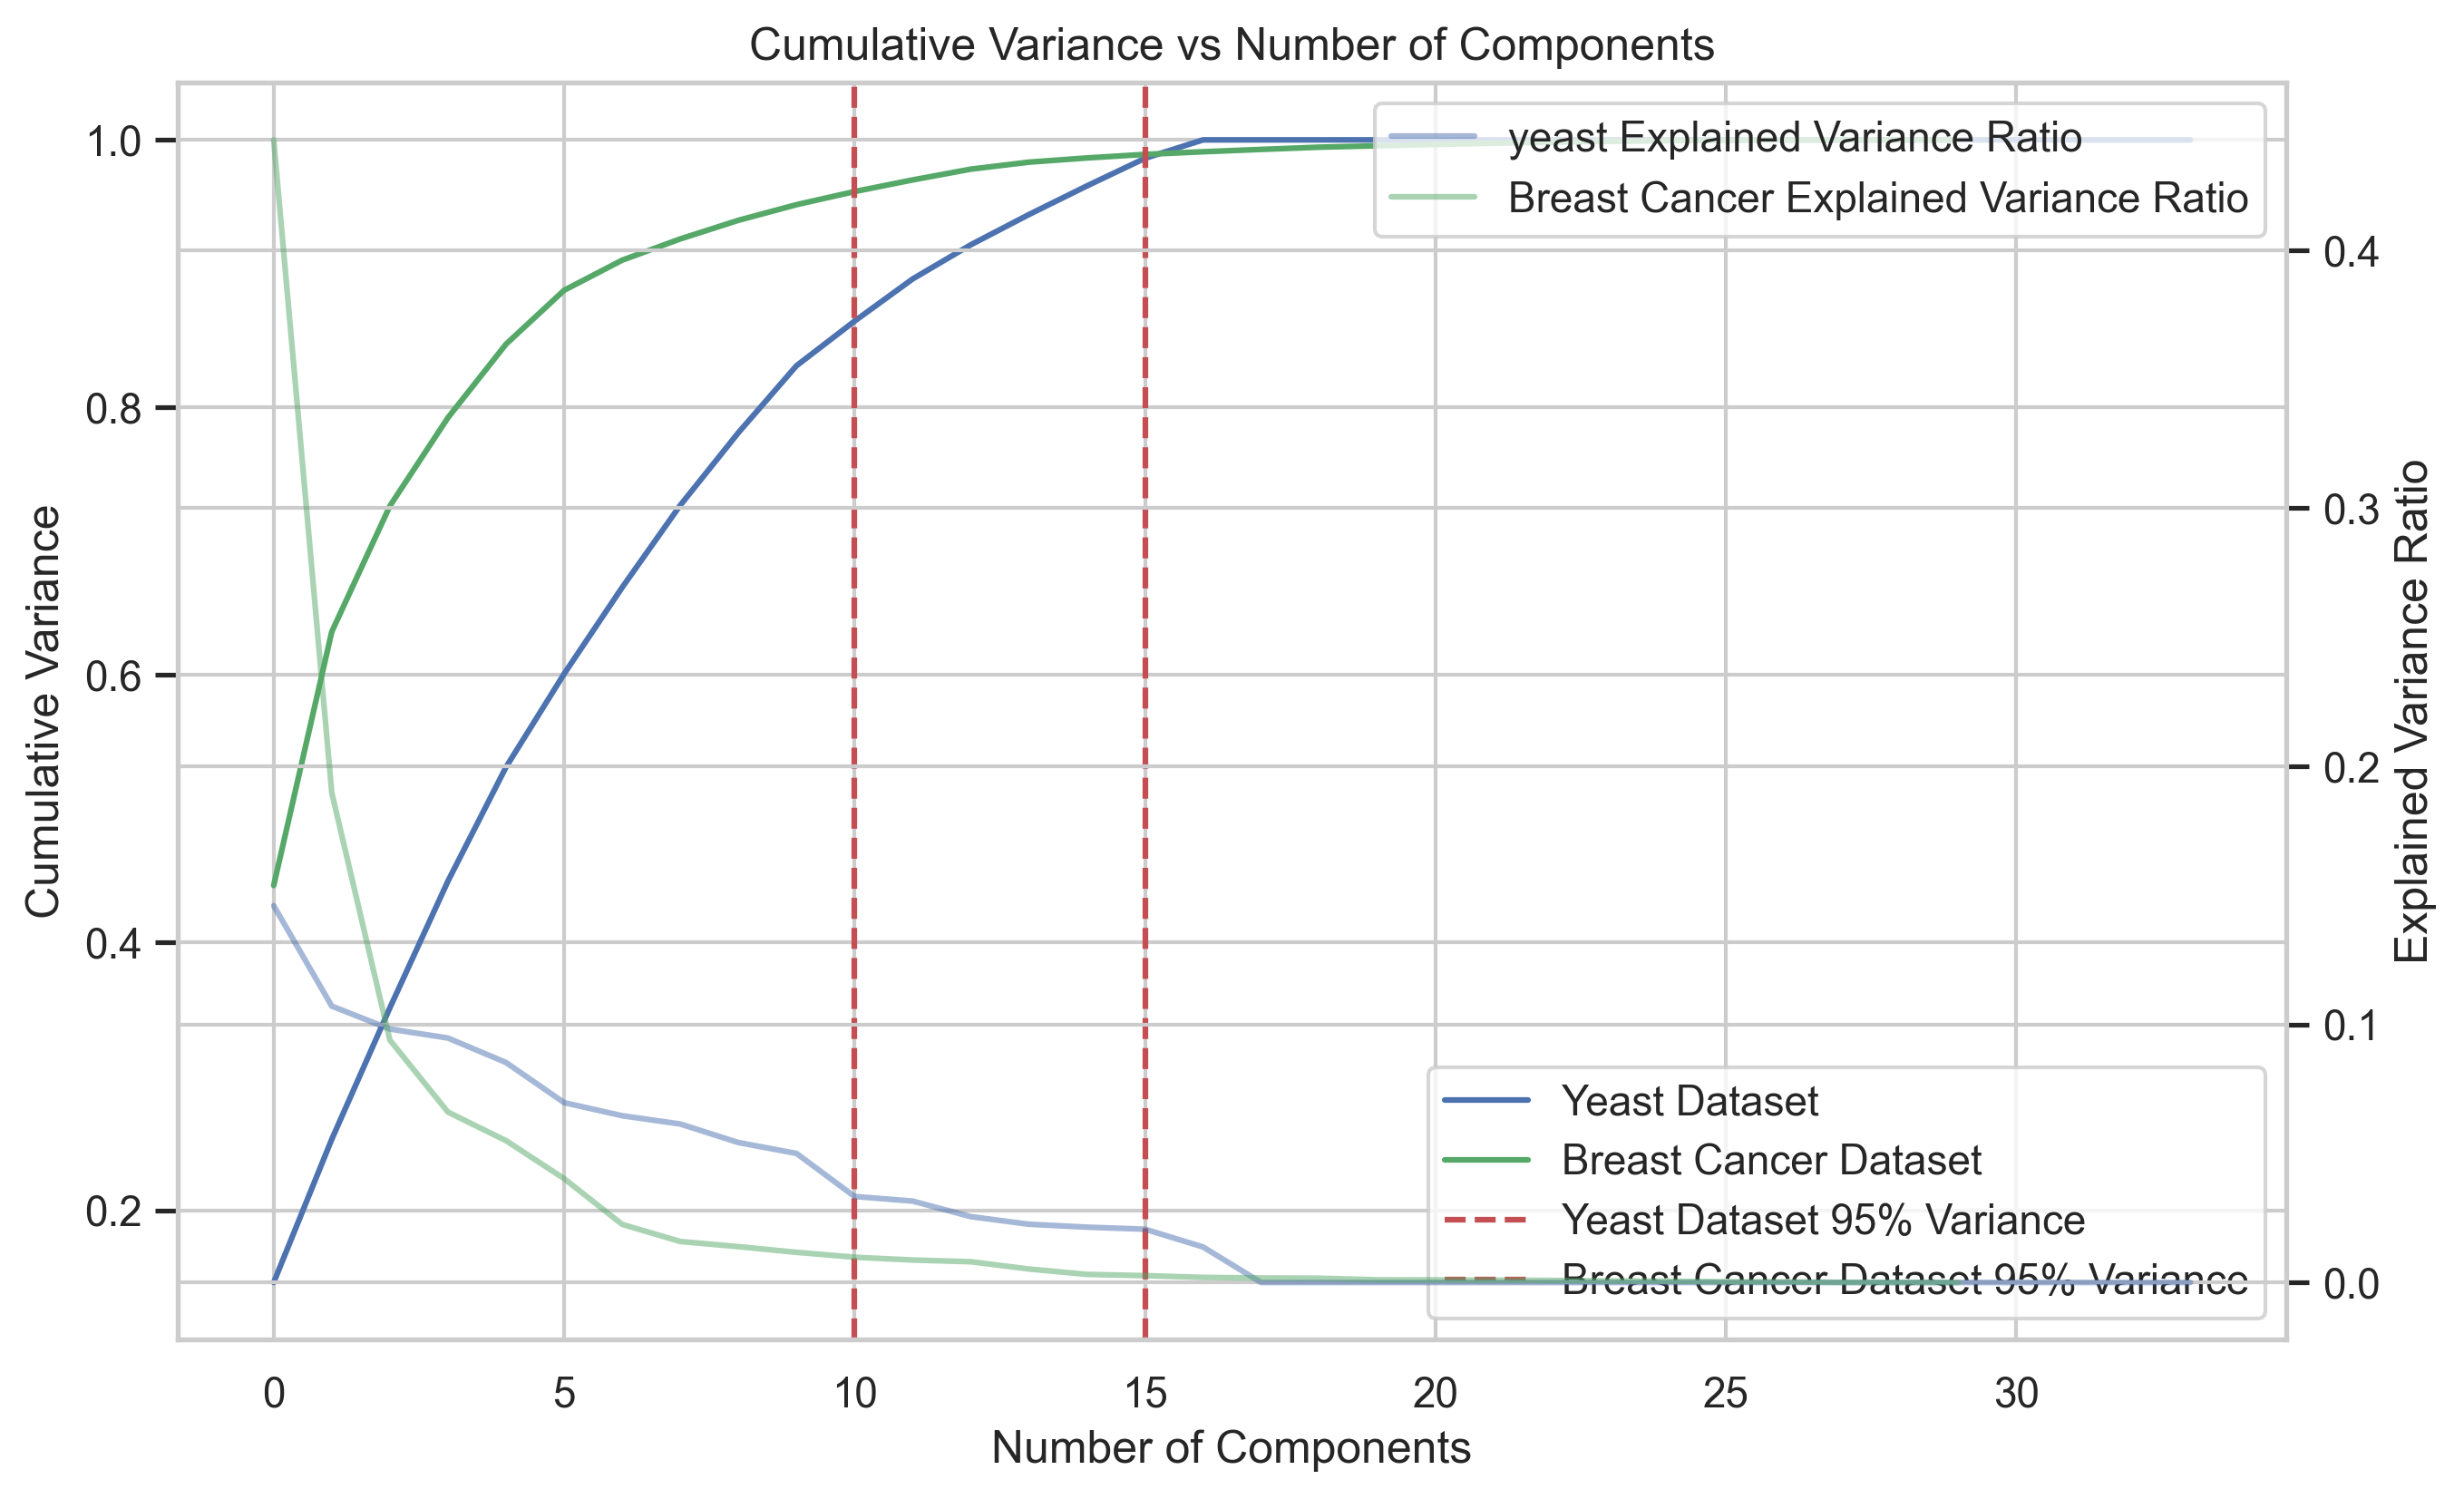

Number of PCA components to capture 95% variance for Yeast dataset: 15
Number of PCA components to capture 95% variance for Breast Cancer dataset: 10


In [131]:
# %%
# Compute number of components to capture 95% variance for PCA
def pca_components_for_variance(data, variance_threshold=0.95):
    data = StandardScaler().fit_transform(data)
    pca = PCA().fit(data)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    num_components = np.argmax(cumulative_variance >= variance_threshold) + 1

    return num_components, cumulative_variance, pca.explained_variance_ratio_


yeast_pca_components, yeast_cumulative_variance, yeast_explained_variance_ratio_ = (
    pca_components_for_variance(yeast_X_standardized)
)
bc_pca_components, bc_cumulative_variance, bc_explained_variance_ratio_ = (
    pca_components_for_variance(bc_X_standardized)
)

# Plot the cumulative variance with elegant style and explained variance ratio on the side
from cProfile import label
from turtle import color
from seaborn import set_palette, set_theme

# use  palette="viridis",
# use seaborn to plot
set_theme(style="whitegrid")
set_palette("viridis", color_codes=True)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(yeast_cumulative_variance, label="Yeast Dataset", color="b")
plt.plot(bc_cumulative_variance, label="Breast Cancer Dataset", color="g")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance vs Number of Components")
plt.axvline(
    yeast_pca_components, color="r", linestyle="--", label="Yeast Dataset 95% Variance"
)
plt.axvline(
    bc_pca_components,
    color="r",
    linestyle="--",
    label="Breast Cancer Dataset 95% Variance",
)
plt.legend(loc="best")
# Add the explained variance ratio on the side
plt.twinx()
plt.plot(
    yeast_explained_variance_ratio_,
    color="b",
    alpha=0.5,
    label="yeast Explained Variance Ratio",
)
plt.plot(
    bc_explained_variance_ratio_,
    color="g",
    alpha=0.5,
    label="Breast Cancer Explained Variance Ratio",
)
plt.ylabel("Explained Variance Ratio")
plt.legend(loc="best")

plt.savefig("./result/cumulative_variance.png")
plt.show()


print(
    f"Number of PCA components to capture 95% variance for Yeast dataset: {yeast_pca_components}"
)
print(
    f"Number of PCA components to capture 95% variance for Breast Cancer dataset: {bc_pca_components}"
)

/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Number of ICA components with valid kurtosis for Yeast dataset: 14
Number of ICA components with valid kurtosis for Breast Cancer dataset: 28


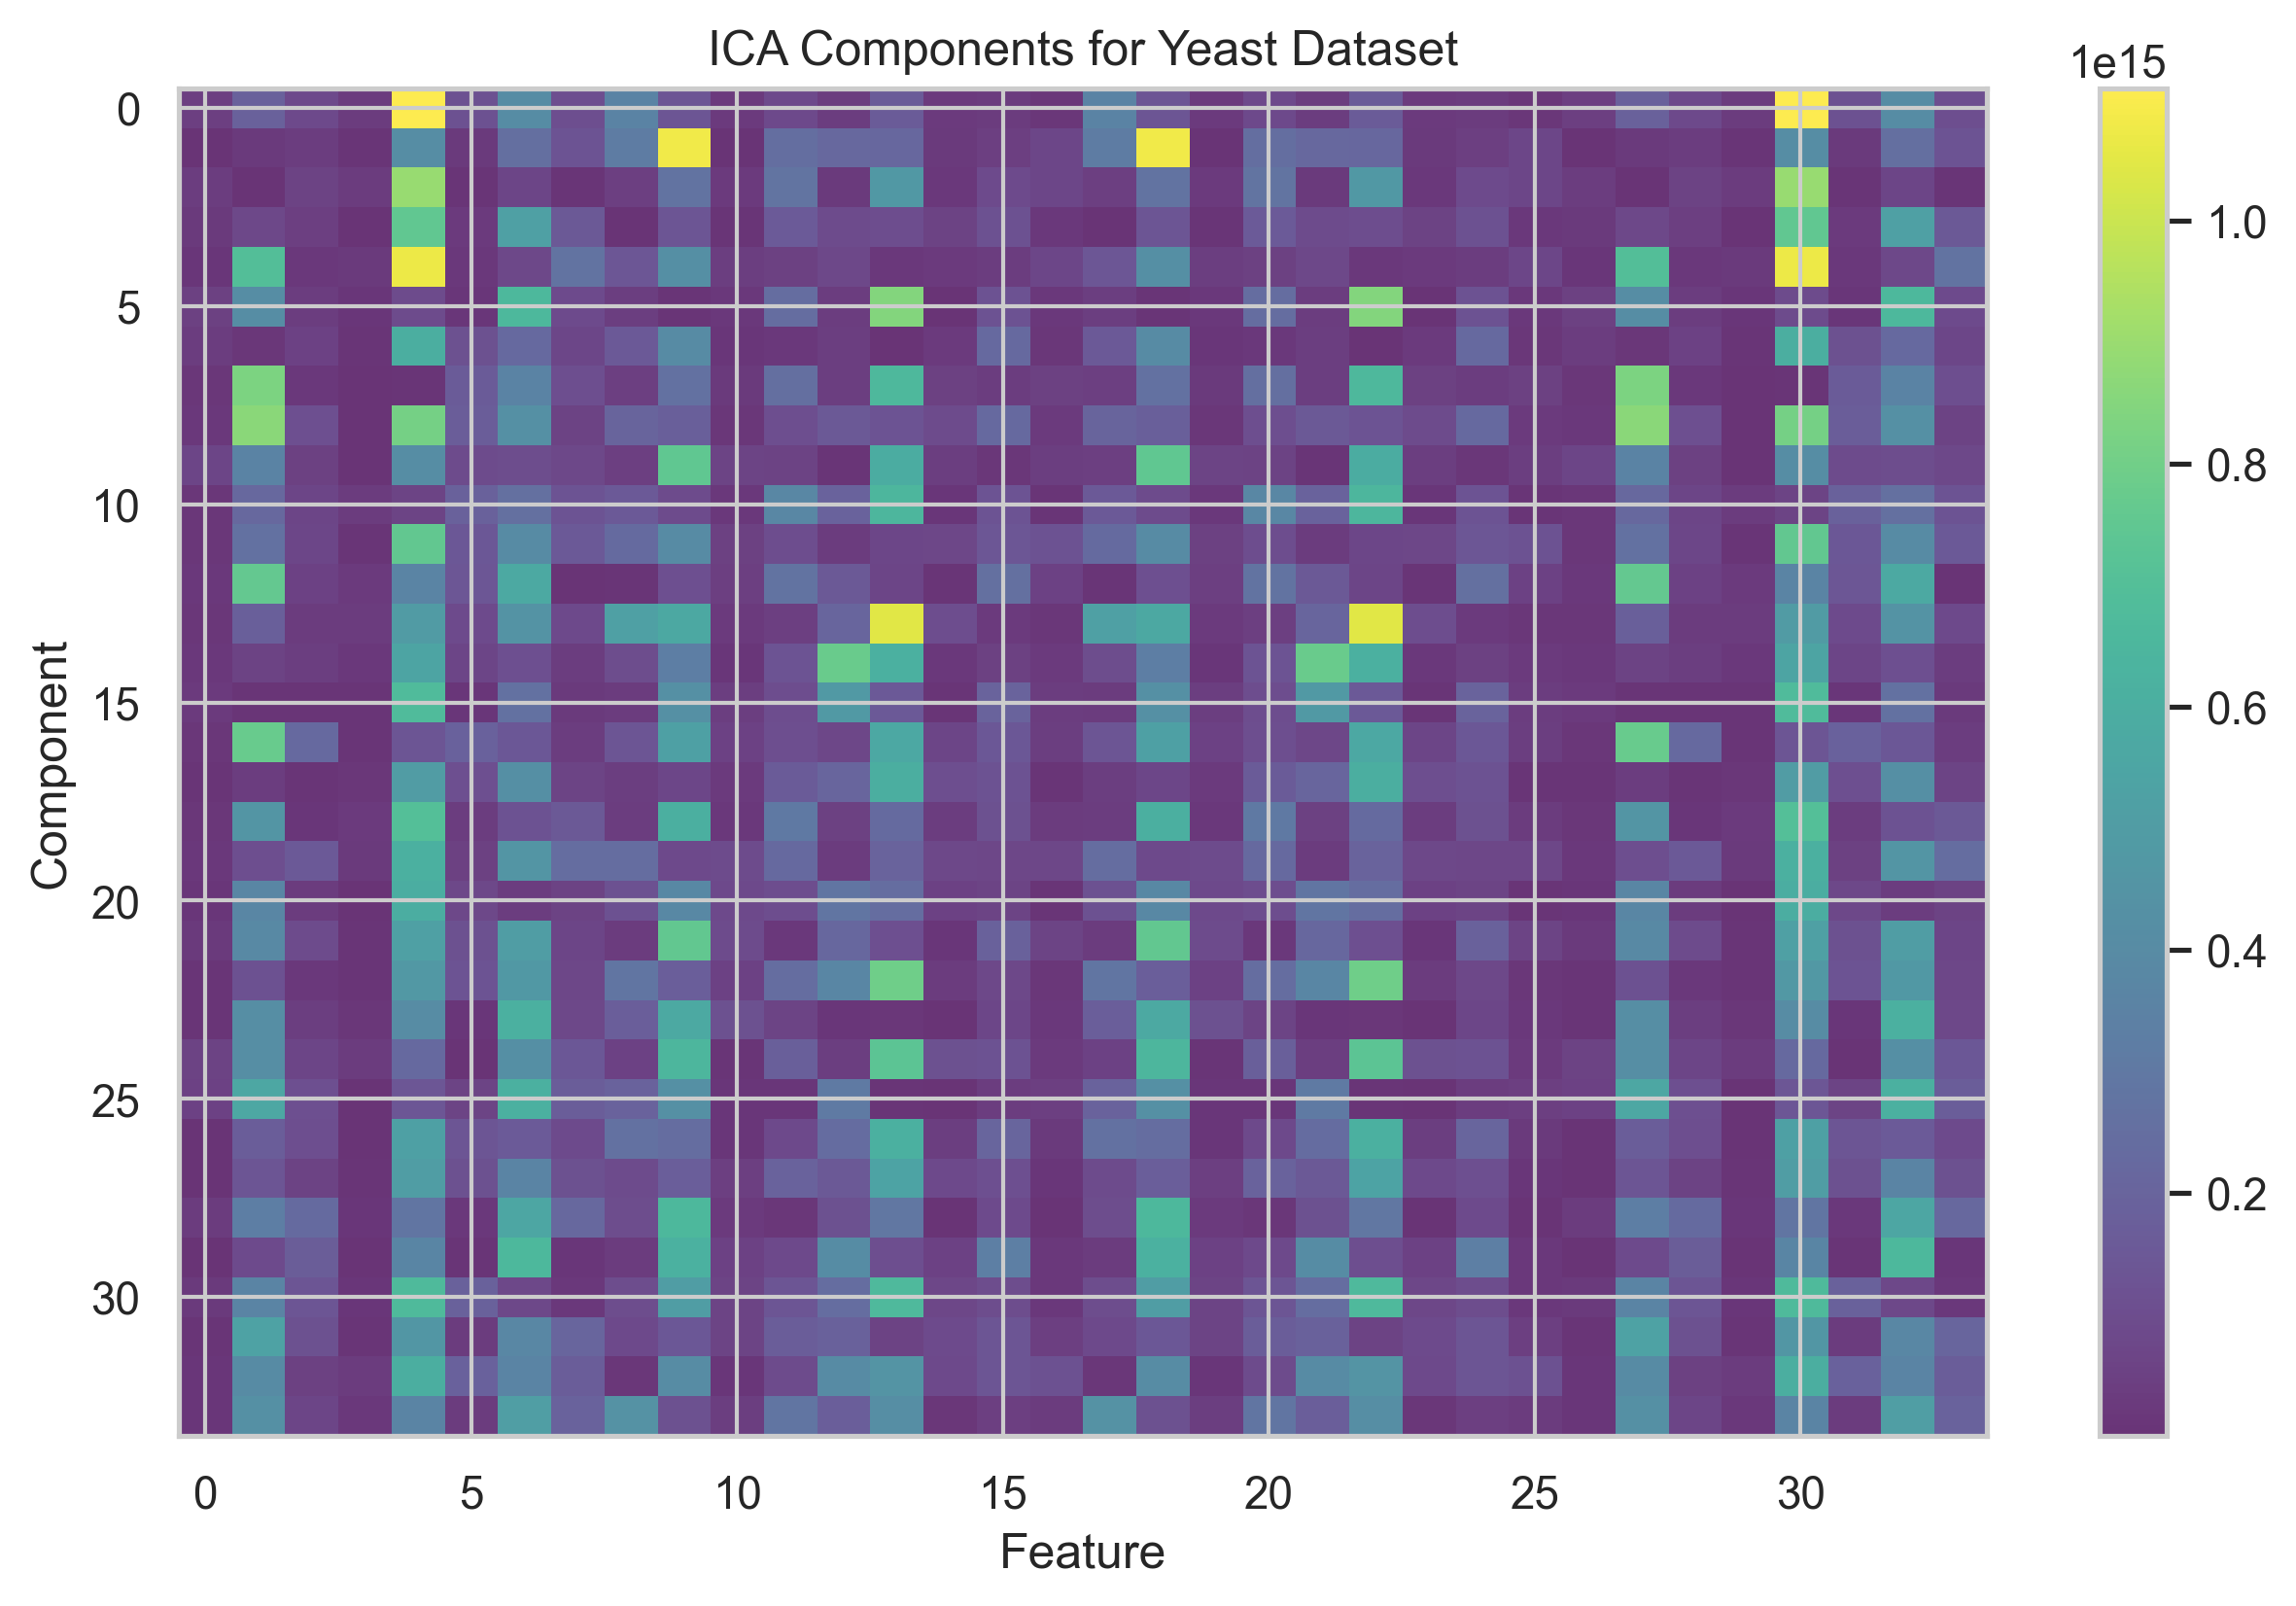

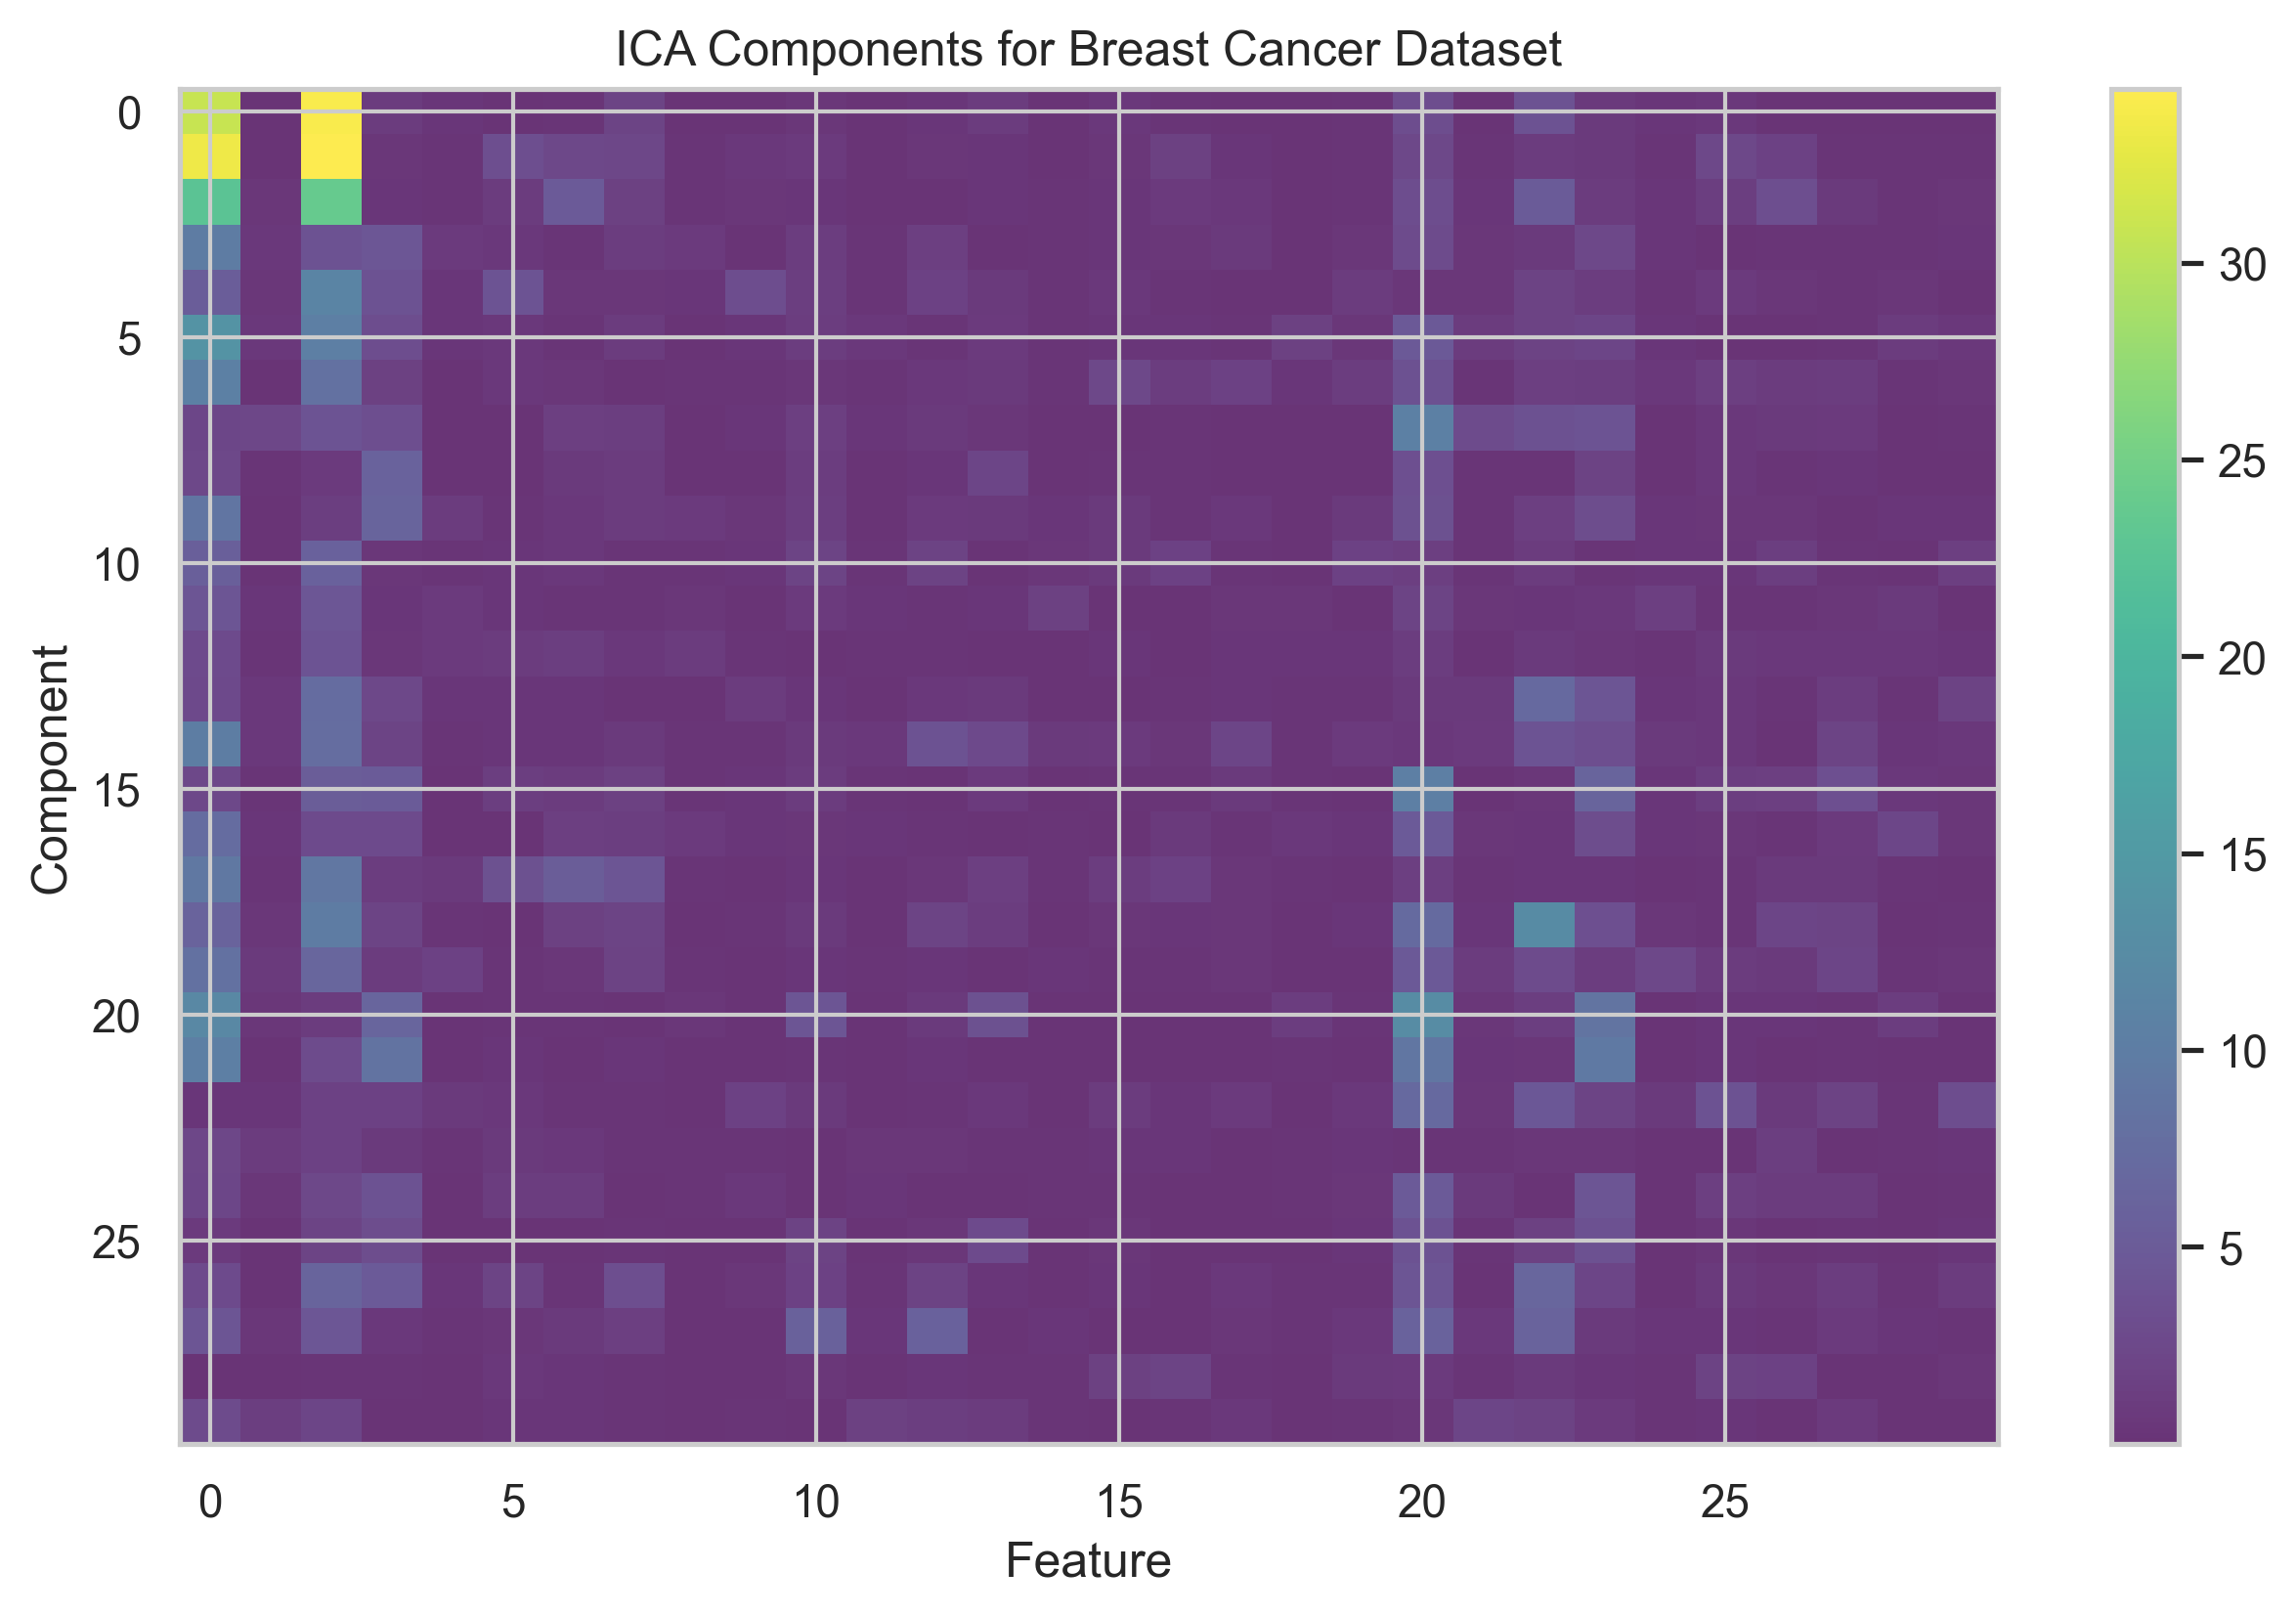

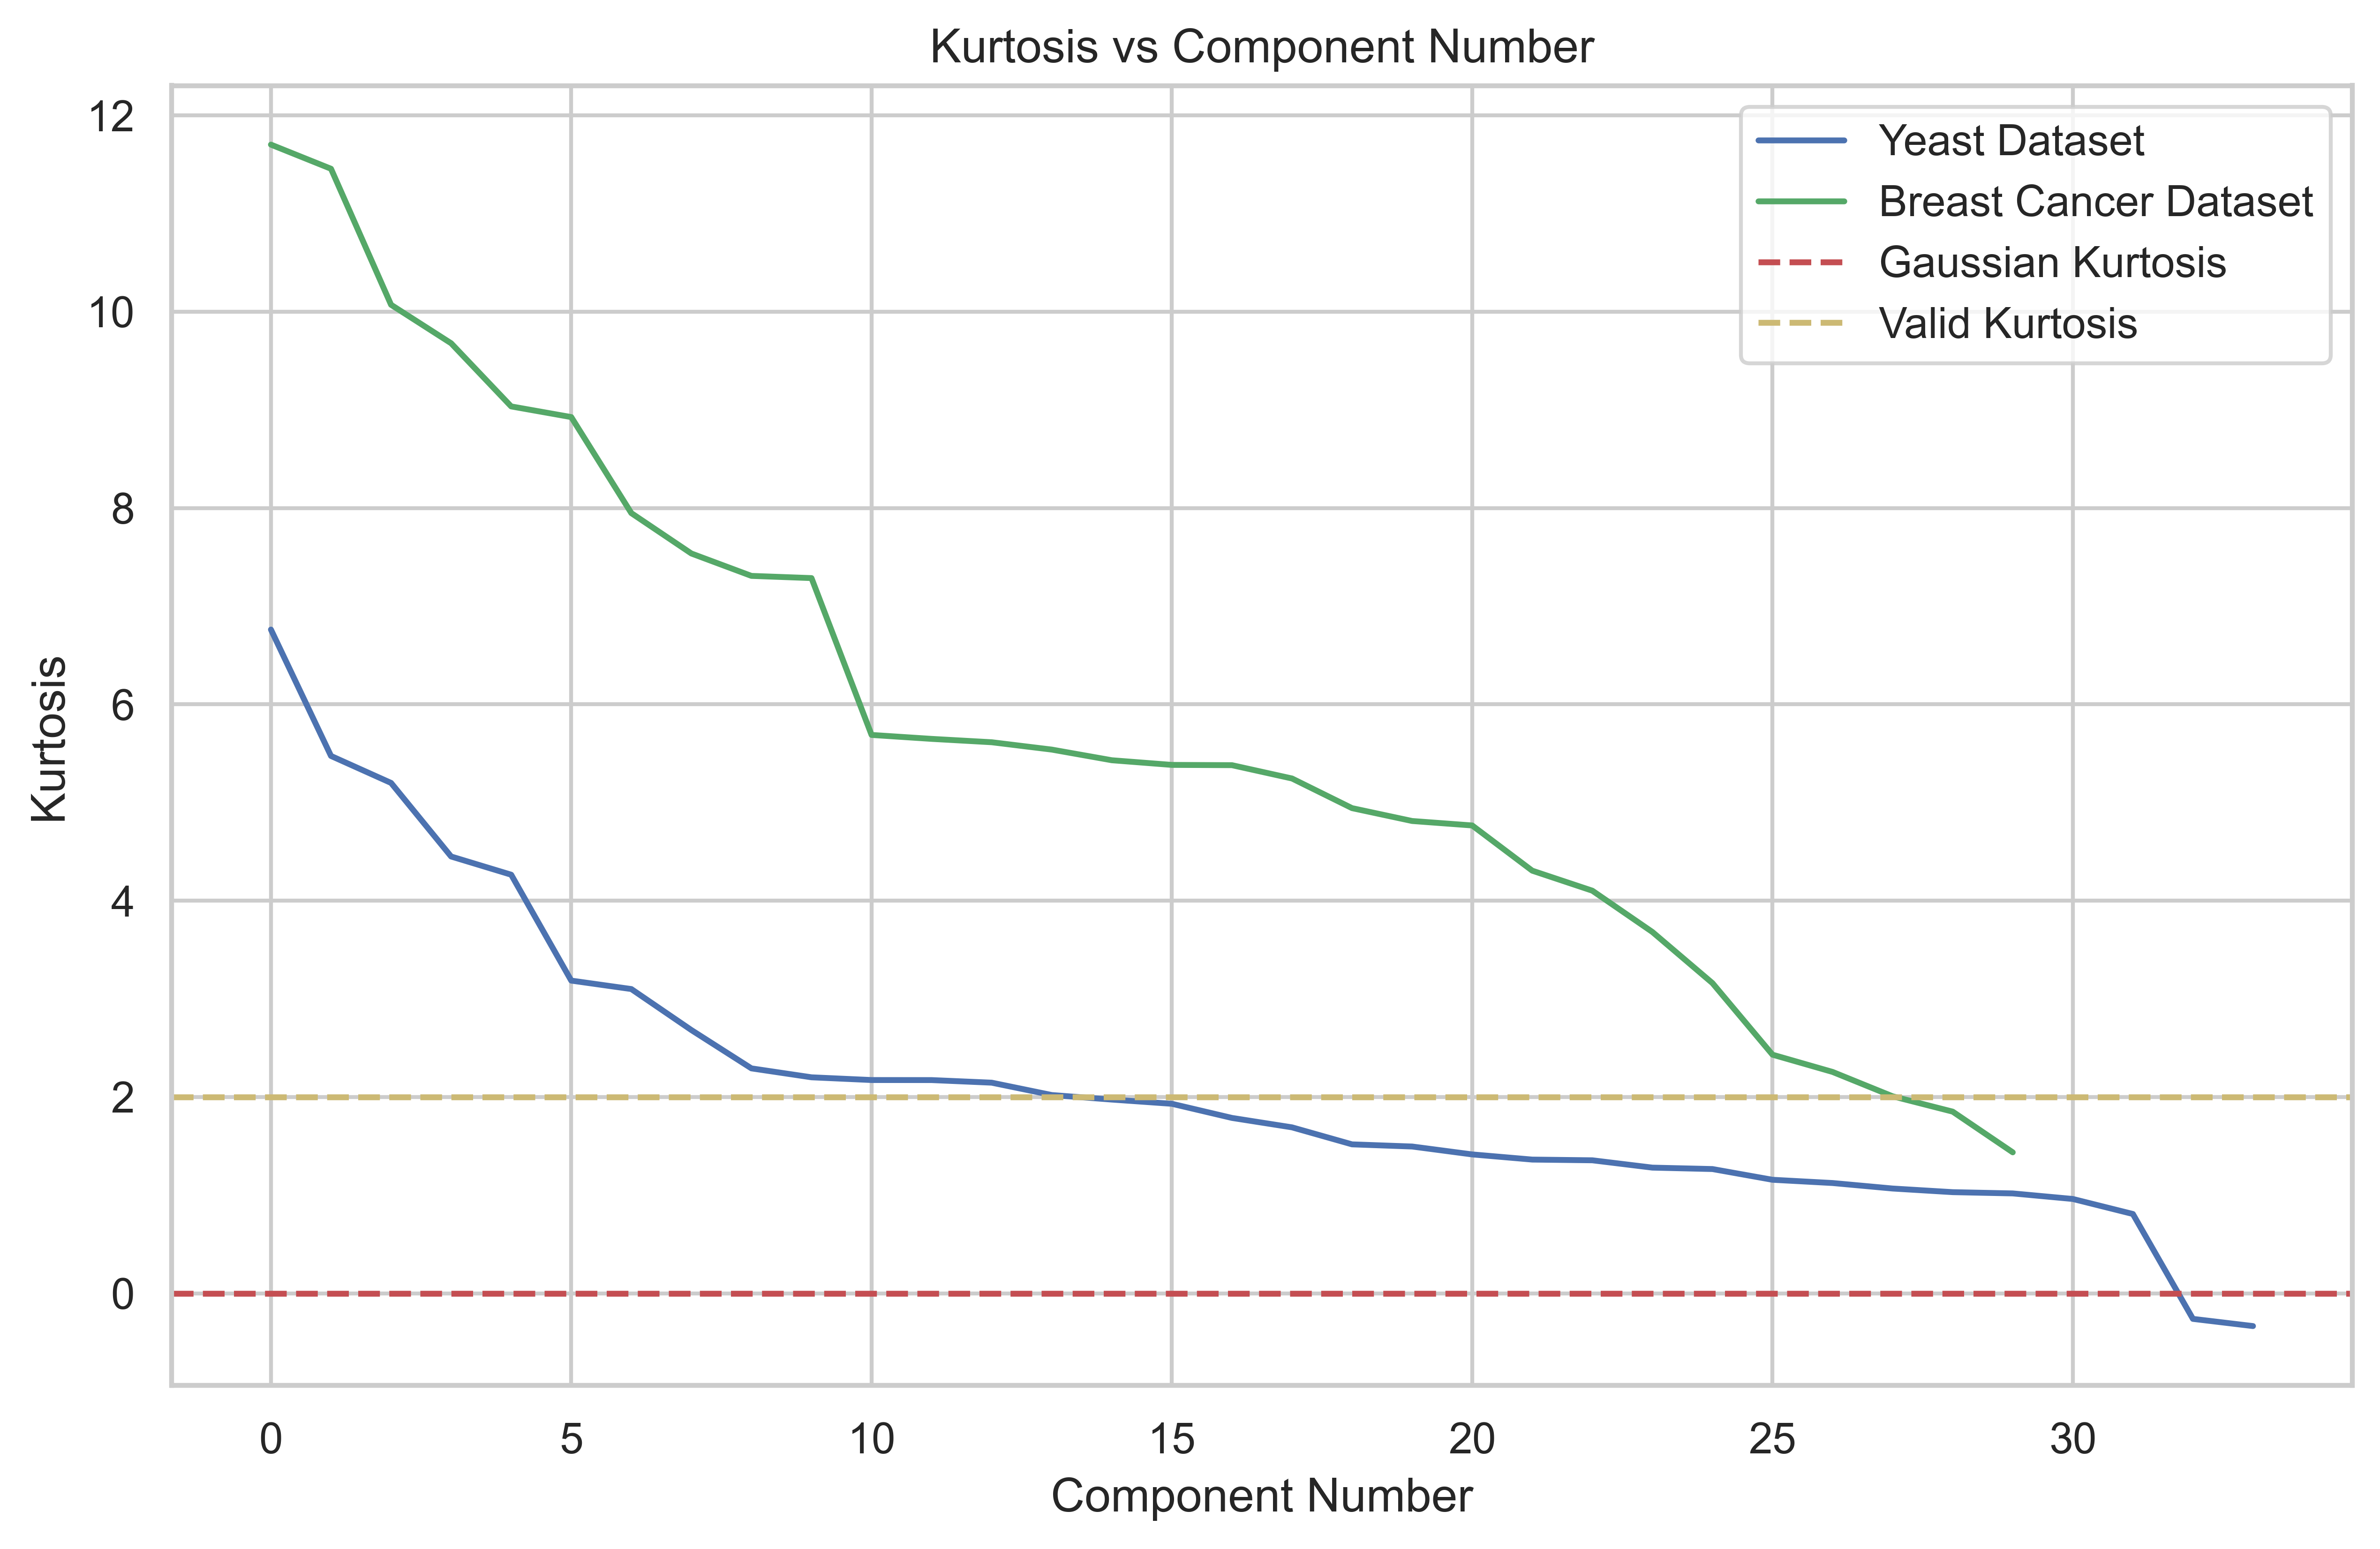

In [132]:
# %%
# Draw the distribution of the kurtosis of the PCA components
from numpy import sort
from pandas import DataFrame
import scipy


def ica_components(data, columns, name=""):
    n_components = data.shape[1]
    ica = FastICA(n_components=n_components, random_state=50)
    ica.fit_transform(data)
    components = ica.components_
    kurtosis = scipy.stats.kurtosis(components, axis=1)
    # sort the components by kurtosis
    sorted_kurtosis = np.sort(kurtosis)[::-1]
    sorted_components = DataFrame(
        np.abs(components[np.argsort(kurtosis)[::-1]]), columns=columns
    )
    # plot hot map
    plt.figure(figsize=(10, 6), dpi=300)
    plt.imshow(
        sorted_components,
        aspect="auto",
        cmap="viridis",
        interpolation="nearest",
        alpha=0.8,
    )
    plt.colorbar()
    plt.xlabel("Feature")
    plt.ylabel("Component")
    plt.title(f"ICA Components for {name} Dataset")
    plt.savefig(f"./result/ica_components_{name}.png")
    return sorted_kurtosis


yeast_ica_components = ica_components(
    yeast_X_standardized, columns=yeast_features.columns, name="Yeast"
)
bc_ica_components = ica_components(
    bc_X_standardized, columns=bc_data.feature_names, name="Breast Cancer"
)

plt.figure(figsize=(10, 6), dpi=600)
plt.plot(yeast_ica_components, label="Yeast Dataset", color="b")
plt.plot(bc_ica_components, label="Breast Cancer Dataset", color="g")
plt.axhline(0, color="r", linestyle="--", label="Gaussian Kurtosis")
plt.axhline(2, color="y", linestyle="--", label="Valid Kurtosis")
plt.xlabel("Component Number")
plt.ylabel("Kurtosis")
plt.title("Kurtosis vs Component Number")
plt.legend(loc="best")
plt.savefig(f"./result/kurtosis.png")
# count the number of valid kurtosis which is greater than 2
number_of_valid_kurtosis_yeast = np.sum(yeast_ica_components > 2)
number_of_valid_kurtosis_bc = np.sum(bc_ica_components > 2)

print(
    f"Number of ICA components with valid kurtosis for Yeast dataset: {number_of_valid_kurtosis_yeast}"
)
print(
    f"Number of ICA components with valid kurtosis for Breast Cancer dataset: {number_of_valid_kurtosis_bc}"
)

In [144]:
# %%


# Compute reconstruction error for PCA, ICA, and Random Projection
from sklearn.random_projection import GaussianRandomProjection


def compute_reconstruction_error(method, data, n_components, random_state=50):
    if method == "pca":
        transformer = PCA(n_components=n_components)
    elif method == "ica":
        transformer = FastICA(n_components=n_components)
    elif method == "rp":
        transformer = GaussianRandomProjection(
            n_components=n_components, random_state=random_state
        )
    else:
        raise ValueError("Invalid method")

    data_transformed = transformer.fit_transform(data)
    data_reconstructed = transformer.inverse_transform(data_transformed)
    return mean_squared_error(data, data_reconstructed)

Number of components to capture 95% variance for Yeast dataset: 33
Number of components to capture 95% variance for Breast Cancer dataset: 29


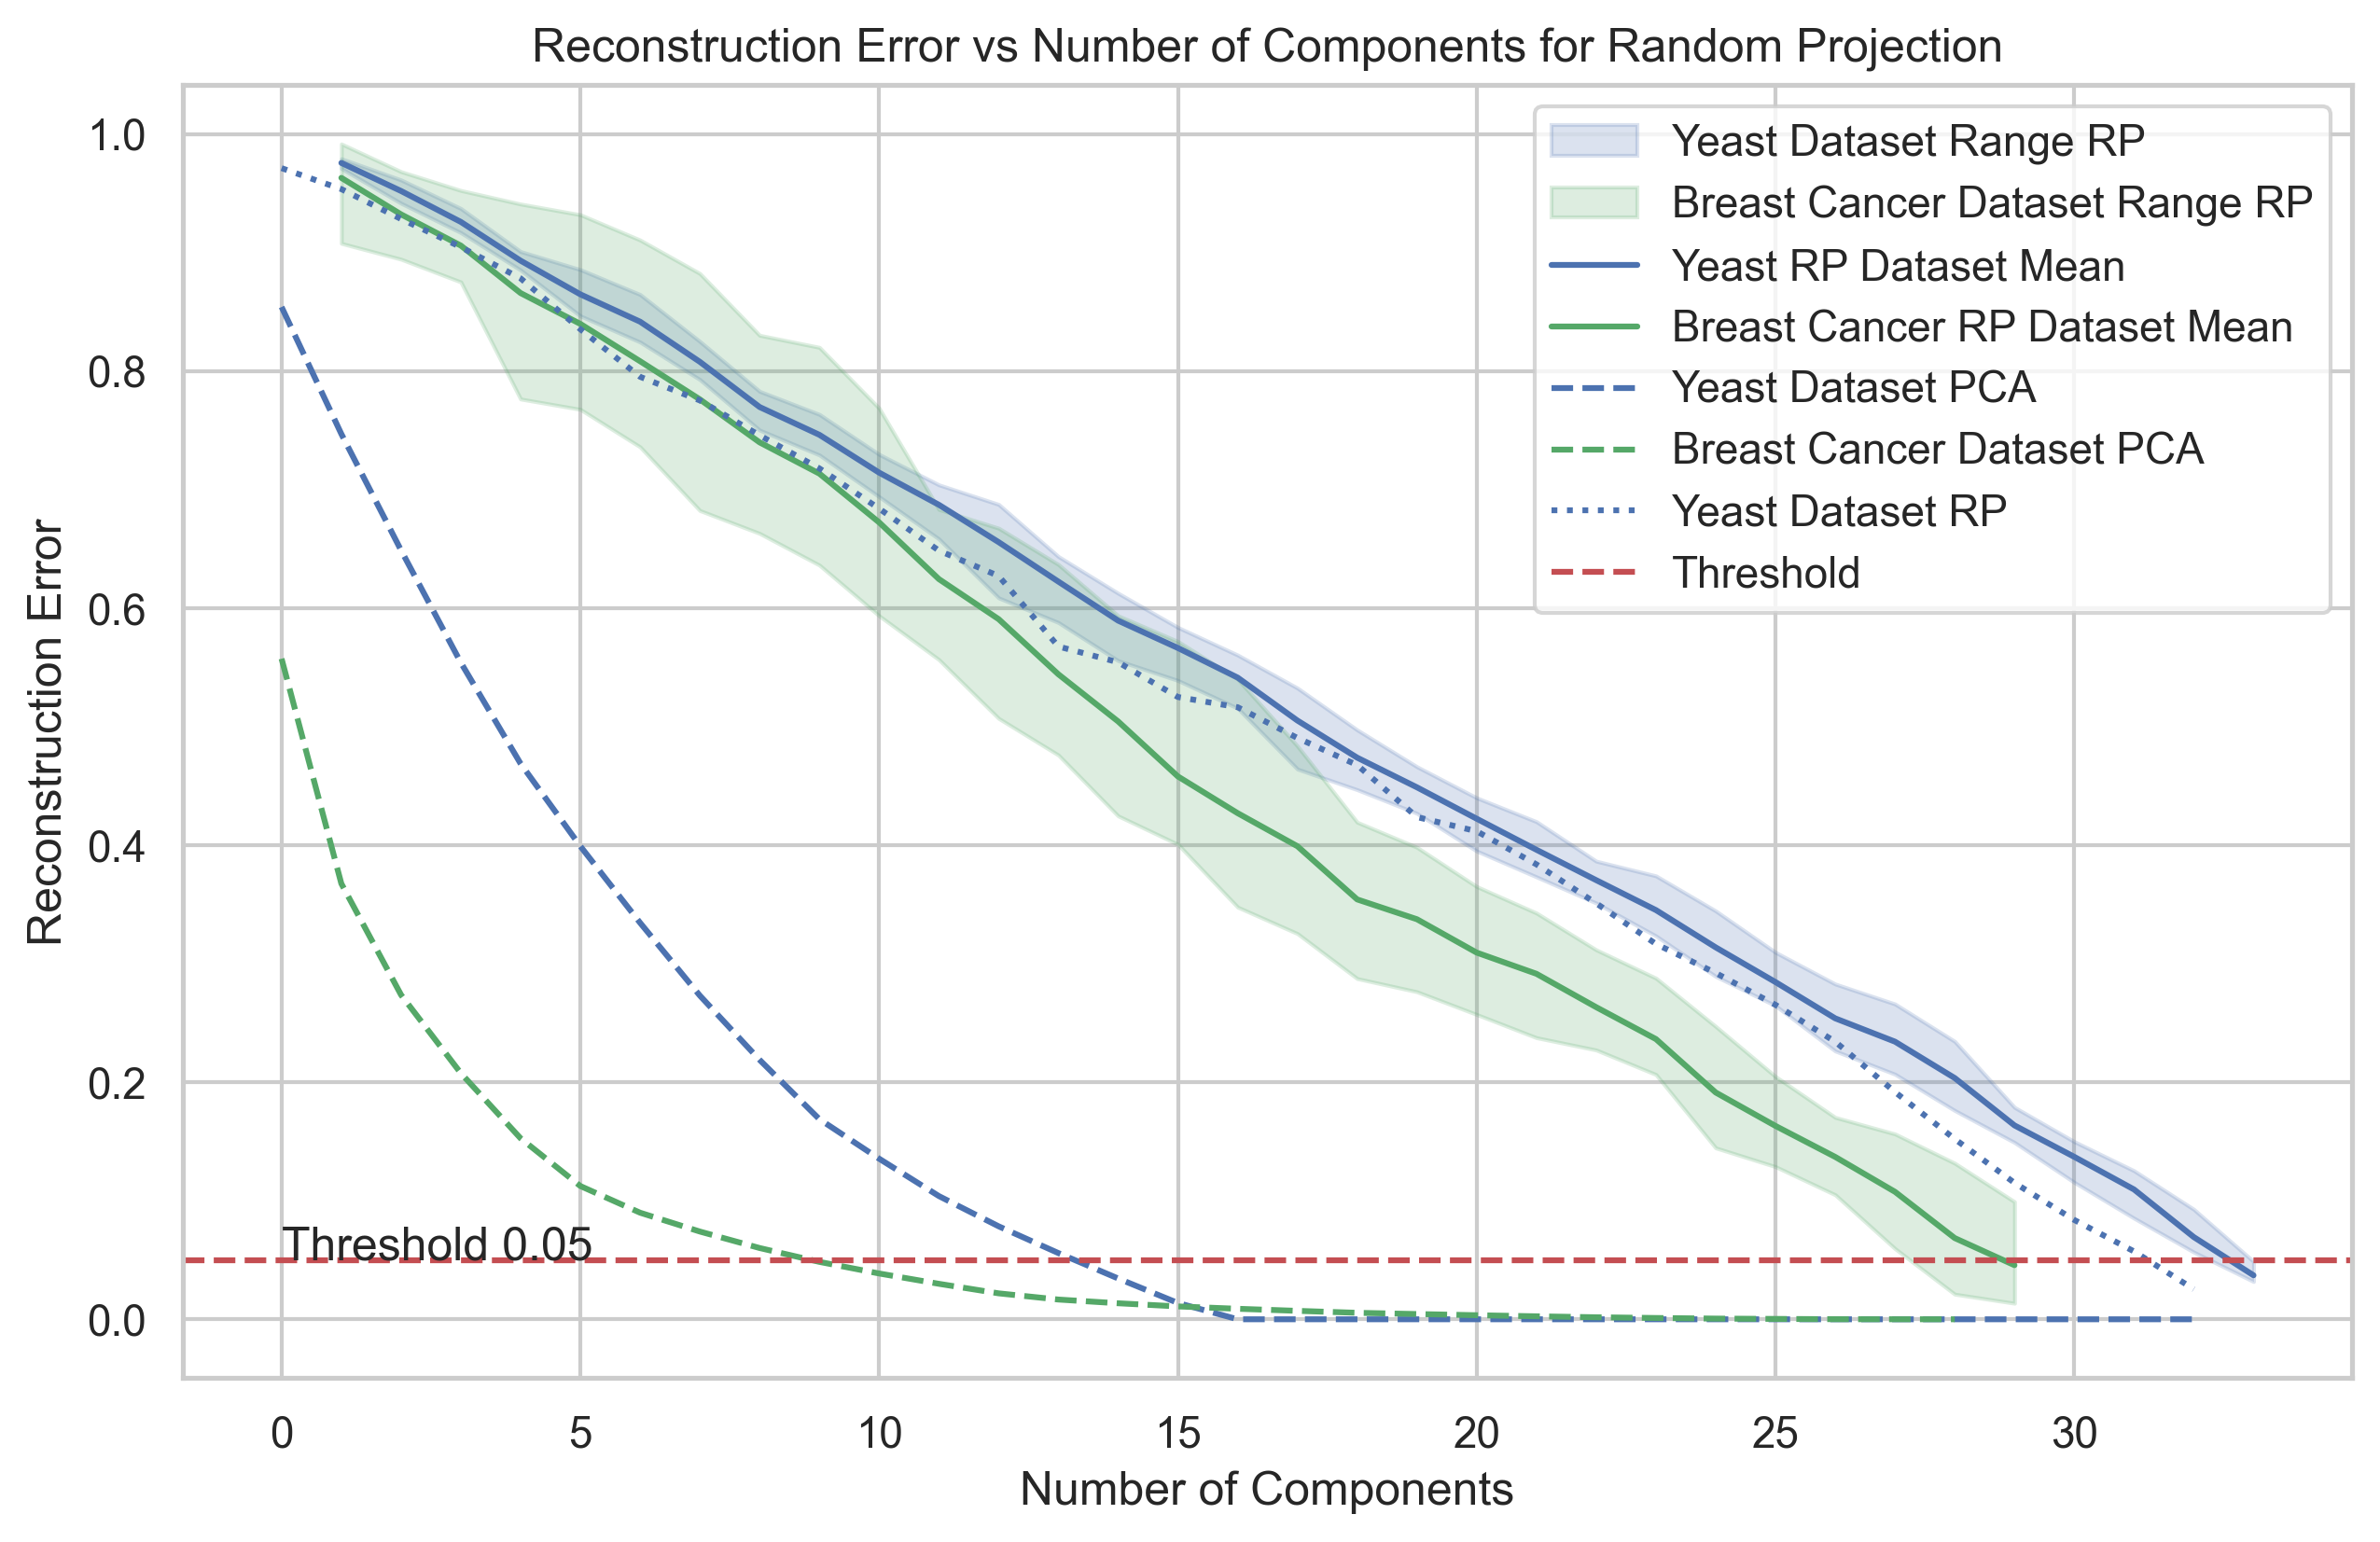

In [158]:
# Compute the reconstruction error for random projection as we remove the number of components
yeast_rp_reconstruction_error = []
bc_rp_reconstruction_error = []
yeast_pca_reconstruction_error = []
bc_pca_reconstruction_error = []
yeast_ica_reconstruction_error = []
bc_ica_reconstruction_error = []

for n_components in range(1, yeast_X_standardized.shape[1]):
    yeast_rp_reconstruction_error.append(
        compute_reconstruction_error("rp", yeast_X_standardized, n_components)
    )
    yeast_pca_reconstruction_error.append(
        compute_reconstruction_error("pca", yeast_X_standardized, n_components)
    )


for n_components in range(1, bc_X_standardized.shape[1]):
    bc_rp_reconstruction_error.append(
        compute_reconstruction_error("rp", bc_X_standardized, n_components)
    )
    bc_pca_reconstruction_error.append(
        compute_reconstruction_error("pca", bc_X_standardized, n_components)
    )
# run RP with different random states and plot the reconstruction error
yeast_rp_reconstruction_errors = DataFrame(
    index=[0, 1, 2], columns=range(1, yeast_X_standardized.shape[1]), dtype=float
)
bc_rp_reconstruction_errors = DataFrame(
    index=[0, 1, 2], columns=range(1, bc_X_standardized.shape[1]), dtype=float
)
for i in range(5):
    for n_components in range(1, yeast_X_standardized.shape[1]):
        yeast_rp_reconstruction_errors.loc[i, n_components] = (
            compute_reconstruction_error(
                "rp", yeast_X_standardized, n_components, random_state=i
            )
        )
    for n_components in range(1, bc_X_standardized.shape[1]):
        bc_rp_reconstruction_errors.loc[i, n_components] = compute_reconstruction_error(
            "rp", bc_X_standardized, n_components, random_state=i
        )

plt.figure(figsize=(10, 6), dpi=300)

plt.fill_between(
    yeast_rp_reconstruction_errors.columns,
    yeast_rp_reconstruction_errors.min(),
    yeast_rp_reconstruction_errors.max(),
    color="b",
    alpha=0.2,
    label="Yeast Dataset Range RP",
)
plt.fill_between(
    bc_rp_reconstruction_errors.columns,
    bc_rp_reconstruction_errors.min(),
    bc_rp_reconstruction_errors.max(),
    color="g",
    alpha=0.2,
    label="Breast Cancer Dataset Range RP",
)
plt.plot(
    yeast_rp_reconstruction_errors.mean(), label="Yeast RP Dataset Mean", color="b"
)
plt.plot(
    bc_rp_reconstruction_errors.mean(), label="Breast Cancer RP Dataset Mean", color="g"
)
plt.plot(
    yeast_pca_reconstruction_error, label="Yeast Dataset PCA", color="b", linestyle="--"
)

plt.plot(
    bc_pca_reconstruction_error,
    label="Breast Cancer Dataset PCA",
    color="g",
    linestyle="--",
)
plt.plot(
    yeast_rp_reconstruction_error, label="Yeast Dataset RP", color="b", linestyle=":"
)
plt.axhline(0.05, color="r", linestyle="--", label="Threshold")
# how to mark 0.05 on the y-axis?
plt.annotate(
    "Threshold 0.05",
    xy=(0, 0.05),
    xytext=(0, 0.05),
    textcoords="offset points",
)
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs Number of Components for Random Projection")
plt.legend(loc="best")
plt.savefig("./result/reconstruction_error_rp.png")
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs Number of Components for Random Projection")
plt.legend(loc="best")
plt.savefig("./result/reconstruction_error_rp_random_state.png")

print(f"Number of components to capture 95% variance for Yeast dataset: 33")
print(f"Number of components to capture 95% variance for Breast Cancer dataset: 29")